# Data Exploration

This notebook:

1. Loads the processed Oxford battery dataset.
2. Downloads the cached dataset automatically if it is not already available.
3. Explores battery degradation over time.
4. Produces the figures used throughout the project.

**Expected runtime:** ~30–60 seconds.


To run the notebook using the default dataset to see a full workflow without interaction, set

    USE_DEFAULTS = False

Change to

    USE_DEFAULTS = True

for full interaction.

In [5]:
from pathlib import Path
import sys
import os
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
project_root_abs = os.path.abspath(PROJECT_ROOT)
sys.path.insert(0, project_root_abs)

from src.plotter import spines
from src.loader import load_oxford_dataset

df = load_oxford_dataset("C1dc")
df.head()

USE_DEFAULTS = True # True = runs presets silently | False = uses custom options below

## Data import

Reading in data extracted in Notebook 1

In [2]:
df = load_oxford_dataset("C1dc")
display(df)

Reading cached Parquet dataset:
/Users/stephencurran/steviecurran.github.io/battery-degradation-prediction/github/data/Oxford_Battery_Dataset_Test=C1dc.parquet


,Cell,Cycle,Test,Time_min,Voltage_V,Charge_mAh,Temperature_C
0,1,0,C1dc,0.000000,4.191235,0.000000,40.026463
1,1,0,C1dc,0.016667,4.175756,-0.194831,40.051395
2,1,0,C1dc,0.033333,4.174312,-0.399788,39.988987
3,1,0,C1dc,0.050000,4.172628,-0.604746,39.976521
4,1,0,C1dc,0.066667,4.171545,-0.809702,39.964054
...,...,...,...,...,...,...,...
1610373,8,8100,C1dc,45.283278,2.750167,-558.299455,41.591419
1610374,8,8100,C1dc,45.299945,2.735212,-558.504936,41.603924
1610375,8,8100,C1dc,45.316611,2.719576,-558.710416,41.529045
1610376,8,8100,C1dc,45.333278,2.703419,-558.915894,41.653828


## Exploration

### Number of diagnostic cycles each cell was tested over

From the preliminary analysis, we see that not all cells are run for the same number of cycles, with Cells 4 to 6, suggesting either accelerated degradation or a shorter experimental observation window.

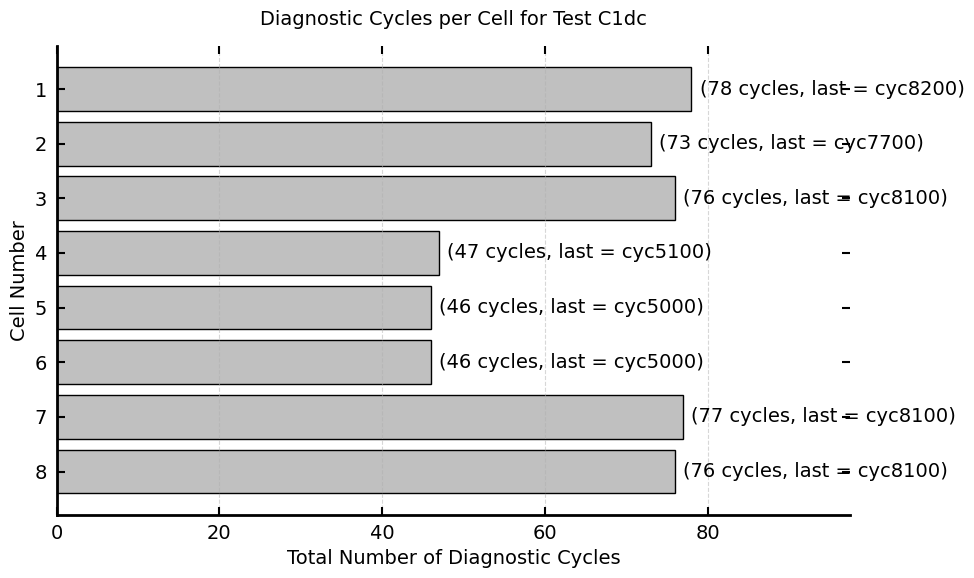

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

test = df['Test'].iloc[1]

summary = df.groupby('Cell')['Cycle'].agg(total_cycles='nunique',last_cycle='max')
summary['Cell_no'] = summary.index
#print(summary)
summary = summary.sort_values('Cell', ascending=False)
    
ax,font = spines(10,6,14,'y')

bars = ax.barh(summary['Cell_no'].astype(str), summary['total_cycles'], 
    color='silver', edgecolor='k',height=0.8)

ax.set_title('Diagnostic Cycles per Cell for Test %s' %(test), fontsize=font, pad=15)
ax.set_xlabel('Total Number of Diagnostic Cycles')
ax.set_ylabel('Cell Number')

ax.set_xlim(0, summary['total_cycles'].max() * 1.25)
ax.grid(axis='x', linestyle='--', alpha=0.5)

for bar, total, last in zip(bars, summary['total_cycles'], summary['last_cycle']):
    width = bar.get_width()
    ax.text(width + 1,bar.get_y() + bar.get_height()/2, 
        f"({total} cycles, last = cyc{last})", 
        va='center', ha='left', color='k')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Cells 4–6 were observed over substantially fewer diagnostic cycles than the remaining cells. At this stage it is unclear whether this reflects accelerated degradation or a shorter experimental campaign.

### Parameter interdependencies

The following allows each of the suppiled parameters ($t,V,q,T$) to be plotted against one another for a variety of cycle numbers.

In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from src.plotter import inter_plot

if USE_DEFAULTS:
    cyc_no   = 5000; xpara = 'Time_min'; ypara = 'Voltage_V'
    save_fmt = 'no'  # Change to 'png', 'eps', etc., to force a static save
else:
    paras = [col for col in df.columns if col not in ['Cell', 'Cycle', 'Test']] if df is not None else ['Time_min', 'Voltage_V', 'Charge_mAh', 'Temperature_C']
    cycle_nos = [0, 1000, 3000, 5000, 8000]

    dd_cyc = widgets.Dropdown(options=cycle_nos, value=5000,
                              description='Cycle No:', layout={'width': '20%'})
    dd_xpara = widgets.Dropdown(options=paras, value='Time_min', 
                                description='X Param:', layout={'width': '25%'})
    dd_ypara = widgets.Dropdown(options=paras, value='Voltage_V', 
                                description='Y Param:', layout={'width': '25%'})
    dd_format = widgets.Dropdown(options=['no','png','eps','pdf','svg'], 
                                 value='no', description='Save:', layout={'width': '20%'})

    menu = widgets.HBox([dd_cyc, dd_xpara, dd_ypara, dd_format])
    
    ui = widgets.VBox([menu])
    
if USE_DEFAULTS:
    inter_plot(df, cyc_no, xpara, ypara, save_fmt)
    
else:
    clear_output(wait=True)
    
    out = widgets.interactive_output(
        inter_plot,
        {'df': widgets.fixed(df), 
            'cyc_no': dd_cyc, 
            'xpara': dd_xpara, 
            'ypara': dd_ypara, 
            'save_fmt': dd_format
        }
    )
    display(ui, out)
    
    # Reset dropdown back to 'no' automatically if in interactive widget mode
    is_resetting = True
    dd_format.value = 'no'
    is_resetting = False

Output()

**Voltage versus time**

Although all cells exhibit nearly identical discharge behaviour initially, systematic divergence becomes apparent after approximately Cycle 3000. By Cycle 5000, Cell 5 reaches the 2.7 V cutoff significantly earlier than the remaining cells, indicating accelerated degradation.<p>

**Charge versus time**

The near-linear relationship between cumulative charge and time remains almost unchanged throughout the experiment, suggesting that the discharge protocol was performed at an approximately constant current.<p>

**Temperature versus time**

Temperature increases monotonically during discharge for all cells. Cell 8 consistently exhibits the largest temperature rise, whereas the remaining cells differ by less than approximately 1°C.<p>

**Voltage as a function of discharged capacity**

Voltage as a function of cumulative discharged charge provides an alternative view of the degradation process, removing the explicit dependence on elapsed time while highlighting changes in accessible capacity.<p>

**Temperature versus voltage**

Temperature increases progressively as the cell voltage decreases, reaching a broad maximum near 3.7 V before declining towards the end of discharge.<p>
